# Regularized Models Notebook

**Week 4-5** stuff:
- multiple target audio features
- `Dummy`, `Linear`, `Ridge`, and `Lasso` techniques

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LassoCV, LinearRegression, RidgeCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 100)
np.random.seed(42)


In [2]:
SRC_PATH = Path.cwd() / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from project_utils import compute_regression_metrics, ensure_dir, ensure_processed_data


In [3]:
data_parts = ensure_processed_data(data_dir="data", processed_dir="data/processed", random_state=42)
train_df = data_parts["train"]
val_df = data_parts["val"]
test_df = data_parts["test"]

print("Train/Val/Test shapes:", train_df.shape, val_df.shape, test_df.shape)


Train/Val/Test shapes: (91259, 14) (19556, 14) (19556, 14)


In [4]:
proposal_targets = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "loudness",
    "tempo",
]

available_targets = [t for t in proposal_targets if t in train_df.columns]
if not available_targets:
    raise ValueError("No proposal targets found in the processed dataset.")

available_targets


['danceability', 'energy', 'valence', 'acousticness', 'loudness', 'tempo']

In [5]:
def build_models():
    return {
        "mean_baseline": DummyRegressor(strategy="mean"),
        "linear_regression": Pipeline(
            [
                ("scaler", StandardScaler()),
                ("linearregression", LinearRegression()),
            ]
        ),
        "ridge": Pipeline(
            [
                ("scaler", StandardScaler()),
                ("ridge", RidgeCV(alphas=np.logspace(-3, 3, 30), cv=5)),
            ]
        ),
        "lasso": Pipeline(
            [
                ("scaler", StandardScaler()),
                (
                    "lasso",
                    LassoCV(
                        alphas=np.logspace(-4, 1, 40),
                        cv=5,
                        max_iter=20000,
                        random_state=42,
                    ),
                ),
            ]
        ),
    }

rows = []
param_rows = []

for target in available_targets:
    feature_cols = [c for c in train_df.columns if c != target]

    X_train, y_train = train_df[feature_cols], train_df[target]
    X_val, y_val = val_df[feature_cols], val_df[target]
    X_test, y_test = test_df[feature_cols], test_df[target]

    for model_name, model in build_models().items():
        fitted = model.fit(X_train, y_train)

        for split_name, X_split, y_split in [
            ("validation", X_val, y_val),
            ("test", X_test, y_test),
        ]:
            y_pred = fitted.predict(X_split)
            metrics = compute_regression_metrics(y_split, y_pred)
            rows.append(
                {
                    "target": target,
                    "model": model_name,
                    "split": split_name,
                    **metrics,
                    "n_features": len(feature_cols),
                }
            )

        alpha = None
        if model_name == "ridge":
            alpha = fitted.named_steps["ridge"].alpha_
        elif model_name == "lasso":
            alpha = fitted.named_steps["lasso"].alpha_

        if alpha is not None:
            param_rows.append({"target": target, "model": model_name, "best_alpha": float(alpha)})

results_df = pd.DataFrame(rows)
params_df = pd.DataFrame(param_rows)

results_df.head()


/Users/oliviaye/Downloads/yale3/CPSC3810/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/oliviaye/Downloads/yale3/CPSC3810/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/oliviaye/Downloads/yale3/CPSC3810/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/oliviaye/Downloads/yale3/CPSC3810/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/oliviaye/Downloads/yale3/CPSC3810/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/olivia

,target,model,split,mse,mae,r2,n_features
0,danceability,mean_baseline,validation,0.035289,0.153125,-3.572663e-06,13
1,danceability,mean_baseline,test,0.035253,0.152924,-8.320265e-07,13
2,danceability,linear_regression,validation,0.020462,0.114973,4.201414e-01,13
3,danceability,linear_regression,test,0.020519,0.114989,4.179489e-01,13
4,danceability,ridge,validation,0.020462,0.114974,4.201438e-01,13


In [6]:
outputs_dir = ensure_dir("outputs")
results_path = outputs_dir / "regularized_results.csv"
params_path = outputs_dir / "regularized_best_params.csv"
test_results_path = outputs_dir / "regularized_test_results.csv"

results_df.to_csv(results_path, index=False)
params_df.to_csv(params_path, index=False)
results_df[results_df["split"] == "test"].to_csv(test_results_path, index=False)

print(f"Saved -> {results_path}")
print(f"Saved -> {params_path}")
print(f"Saved -> {test_results_path}")


Saved -> outputs/regularized_results.csv
Saved -> outputs/regularized_best_params.csv
Saved -> outputs/regularized_test_results.csv


In [7]:
test_results = results_df[results_df["split"] == "test"].copy()
r2_pivot = test_results.pivot(index="target", columns="model", values="r2")
r2_pivot


model,lasso,linear_regression,mean_baseline,ridge
target,,,,
acousticness,0.564997,0.565006,-4.717791e-06,0.565006
danceability,0.417972,0.417949,-8.320265e-07,0.417951
energy,0.735335,0.735330,-6.482152e-06,0.735331
loudness,0.721361,0.721361,-3.349301e-07,0.721362
tempo,0.068486,0.068463,-1.096647e-05,0.068461
valence,0.292469,0.292444,-8.285051e-05,0.292444


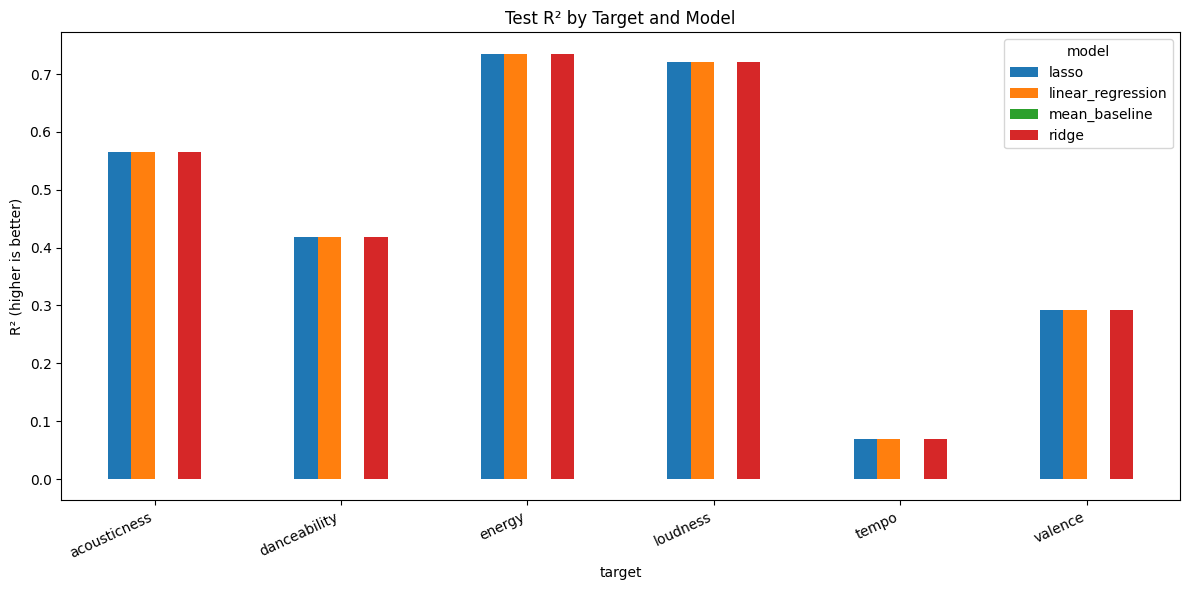

In [8]:
ax = r2_pivot.plot(kind="bar", figsize=(12, 6))
ax.set_ylabel("R² (higher is better)")
ax.set_title("Test R² by Target and Model")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


In [9]:
best_by_target = (
    test_results.sort_values("r2", ascending=False)
    .groupby("target", as_index=False)
    .first()
    .sort_values("r2", ascending=False)
)

best_path = outputs_dir / "best_model_by_target.csv"
best_by_target.to_csv(best_path, index=False)
print(f"Saved -> {best_path}")

best_by_target


Saved -> outputs/best_model_by_target.csv


,target,model,split,mse,mae,r2,n_features
2,energy,lasso,test,0.017964,0.103532,0.735335,13
3,loudness,ridge,test,11.838634,2.417420,0.721362,13
0,acousticness,ridge,test,0.052196,0.180446,0.565006,13
1,danceability,lasso,test,0.020518,0.115003,0.417972,13
5,valence,lasso,test,0.047415,0.177151,0.292469,13
4,tempo,lasso,test,827.878452,23.294725,0.068486,13


## Next Notebook
Run [final.ipynb](final.ipynb) to produce the final comparison charts and submission summary.
